In [33]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [18]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [19]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (10551625, 19)


In [20]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)

CV_filtered_rows after removing April-October: (4616544, 19)


In [21]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152


In [22]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

23 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO 5 ESE', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


In [23]:
# count the number of years of data for each station
station_year_counts = (
    CV_rows
    .drop_duplicates(subset=['STATION', 'year'])
    .groupby('STATION')['year']
    .nunique()
    .sort_values(ascending=False)
)

# make a list of stations with more than 30 years of data
# then filter that list to only include stations with data back to at least 1970
stations_30_years = station_year_counts[station_year_counts > 30].index.tolist()
stations_30_years_pre1970 = [s for s in stations_30_years if s in stations_pre1970]

# print the number of stations with more than 30 years of data
print(len(stations_30_years), "stations with more than 30 years of data")
# print the list of stations with data back to at least 1970
print("stations_30_years_pre1970:", stations_30_years_pre1970)
station_year_counts.loc[stations_30_years_pre1970]

22 stations with more than 30 years of data
stations_30_years_pre1970: ['SACRAMENTO 5 ESE', 'RED BLUFF MUNI AP', 'MODESTO AP', 'BAKERSFIELD AP', 'SACRAMENTO AP ASOS', 'STOCKTON AP', 'FRESNO YOSEMITE INTL', 'TRAVIS FIELD AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO MATHER AFB', 'CASTLE AFB', 'BEALE AFB', 'LEMOORE REEVES NAS', 'CHICO ARMY FLYING SCHOOL', 'MARYSVILLE AIRPORT (ASOS)', 'REDDING AP', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP']


STATION
SACRAMENTO 5 ESE               149
RED BLUFF MUNI AP              135
MODESTO AP                     113
BAKERSFIELD AP                  99
SACRAMENTO AP ASOS              96
STOCKTON AP                     85
FRESNO YOSEMITE INTL            84
TRAVIS FIELD AFB                83
SACRAMENTO MCCLELLAN AFB        80
SACRAMENTO MATHER AFB           80
CASTLE AFB                      76
BEALE AFB                       67
LEMOORE REEVES NAS              66
CHICO ARMY FLYING SCHOOL        58
MARYSVILLE AIRPORT (ASOS)       57
REDDING AP                      55
FRESNO                          42
FRESNO CHANDLER DOWNTOWN AP     32
Name: year, dtype: int64

In [24]:
# Remove stations with 149 or fewer days counted
filtered_days_year_no_outliers = filtered_days_year[filtered_days_year["filtered_days"] > 149].copy()

# Get the valid station-year combinations for merging,
# meaning those that have more than 149 days counted
valid_station_years = filtered_days_year_no_outliers[["STATION", "year"]]
CV_filtered_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", filtered_days_year_no_outliers.shape[0])
print("CV_filtered_rows_no_outliers:", CV_filtered_rows_no_outliers.shape)

Station-years kept: 973
CV_filtered_rows_no_outliers: (3978541, 19)


In [25]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["HourlyVisibility"] < 1.000]

print("CV_filtered_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)

CV_filtered_rows_no_outliers with HourlyVisibility < 1.000: (221673, 19)


In [26]:
# add a new dataframe to count the number of low visibility days per year per station
# with year, month, and day as unique identifiers to avoid double counting
fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [27]:
# print the number of unique years for each station in fog_days_year
station_year_counts = fog_days_year.groupby("STATION")["year"].nunique()
# print the number of stations with at least 30 years of fog data
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter fog_days_year to only include stations with at least 30 years of data
fog_days_year_filtered = fog_days_year[
    fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered fog_days_year rows:", fog_days_year_filtered.shape)

Stations kept: 14
Filtered fog_days_year rows: (785, 3)


In [28]:
# see the first few rows of low visibility data
low_vis_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
128,USM00074917,35.117,-119.3,1942-01-06 08:00:00,SAO,1.3,1.3,0.0,||FG,NaN,0.4,225.0,0.5,1942,1,6,8,0,GARDNER AAF
217,USM00074917,35.117,-119.3,1942-01-10 01:00:00,SAO,7.4,7.4,0.0,||FG,NaN,0.3,203.0,1.5,1942,1,10,1,0,GARDNER AAF
218,USM00074917,35.117,-119.3,1942-01-10 02:00:00,SAO,4.1,5.2,0.0,||FG,OVC:08,0.8,45.0,1.0,1942,1,10,2,0,GARDNER AAF
219,USM00074917,35.117,-119.3,1942-01-10 03:00:00,SAO,4.1,5.2,0.0,||FG,OVC:08,0.4,23.0,0.5,1942,1,10,3,0,GARDNER AAF
223,USM00074917,35.117,-119.3,1942-01-10 07:00:00,SAO,5.2,5.2,0.0,||FG,OVC:08,0.8,225.0,1.5,1942,1,10,7,0,GARDNER AAF


In [29]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
if low_vis_events["DATE"].dtype == object:
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
# below we timedelta999 is used to fill in the first observation's time_diff, which is NaN, with a large value to ensure it starts a new event
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
# below we identify new low-visibility fog events based on a 2.5-hour gap
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=2.5)
# then we assign an event_id to each low-visibility fog event by cumulatively summing the new_event flags within each station
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

# compute summary statistics for each low-visibility fog event
# including start and end times, year, month, and duration in hours
event_summary = (
    low_vis_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "min"),
        end=("DATE", "max"),
        year=("year", "first"),
        month=("month", "first"),
        duration_hours=("event_id", "size"),
    )
)

# compute year_month for event_summary, which will be used for monthly aggregation
event_summary["year_month"] = pd.to_datetime(
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

# compute the number of low visibility days per month per station
monthly_low_vis_days = (
    low_vis_events
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "low_vis_days"})
)

# compute monthly statistics for low-visibility fog events,
# including average duration and number of events, and merge with monthly low visibility days
event_monthly = (
    event_summary
    .groupby(["STATION", "year", "month"], as_index=False)
    .agg(
        avg_event_duration_hours=("duration_hours", "mean"),
        n_events=("duration_hours", "size"),
    )
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

# compute year_month for event_monthly, which will be used for annual aggregation
event_monthly["year_month"] = pd.to_datetime(
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

# compute annual statistics for low-visibility fog events,
# including average duration, total number of events, and average monthly low visibility days
annual_event_stats = (
    event_monthly
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        total_events=("n_events", "sum"),
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

# merge annual_event_stats with fog_days_year_filtered
# to compare the number of fog days with the number of events
annual_compare = fog_days_year_filtered.merge(
    annual_event_stats,
    on=["STATION", "year"],
    how="left"
)

# print the first few rows of annual_compare to check the results
print(annual_compare.head())

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932        15                  2.777778            16   
1  BAKERSFIELD AP  1933        18                  6.550505            20   
2  BAKERSFIELD AP  1934        39                  4.361975            49   
3  BAKERSFIELD AP  1935        21                  3.491758            22   
4  BAKERSFIELD AP  1936        14                  3.583333            17   

   avg_monthly_low_vis_days  
0                      5.00  
1                      6.00  
2                      9.75  
3                      5.25  
4                      2.80  


In [30]:

# Ensure wind direction is numeric; "000" is treated as calm (0, 0)
wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")

# Unit-vector style components from wind direction
# 360 = north, 180 = south, 270 = west, 90 = east
# Determine the north-south component of the wind direction
CV_rows["wind_ns_component"] = np.where(
    wd.eq(0) | wd.isna(),
    0.0,
    np.cos(np.deg2rad(wd))
)

# Determine west-east component of the wind direction
CV_rows["wind_we_component"] = np.where(
    wd.eq(0) | wd.isna(),
    0.0,
    np.sin(np.deg2rad(wd))
)

CV_rows[["HourlyWindDirection", "wind_ns_component", "wind_we_component"]].head()

,HourlyWindDirection,wind_ns_component,wind_we_component
0,0.0,0.000000,0.000000
1,158.0,-0.927184,0.374607
2,0.0,0.000000,0.000000
3,225.0,-0.707107,-0.707107
4,225.0,-0.707107,-0.707107


Total station-component trends tested: 50
Significant trends (p < 0.05): 20
                       STATION    component  n_years  slope_per_year  \
6     CHICO ARMY FLYING SCHOOL  north_south       47        0.003981   
16      LIVERMORE MUNICIPAL AP  north_south       47        0.001803   
26       OROVILLE MUNICIPAL AP  north_south       29       -0.004709   
44            TRAVIS FIELD AFB  north_south       47       -0.002071   
10        FRESNO YOSEMITE INTL  north_south       47        0.001173   
42                 STOCKTON AP  north_south       47        0.001780   
34          SACRAMENTO AP ASOS  north_south       47        0.001195   
22         MERCED MUNICIPAL AP  north_south       44       -0.002090   
0               BAKERSFIELD AP  north_south       47        0.001257   
20   MARYSVILLE AIRPORT (ASOS)  north_south       47        0.000902   
17      LIVERMORE MUNICIPAL AP    west_east       47        0.003239   
3                    BEALE AFB    west_east       47        

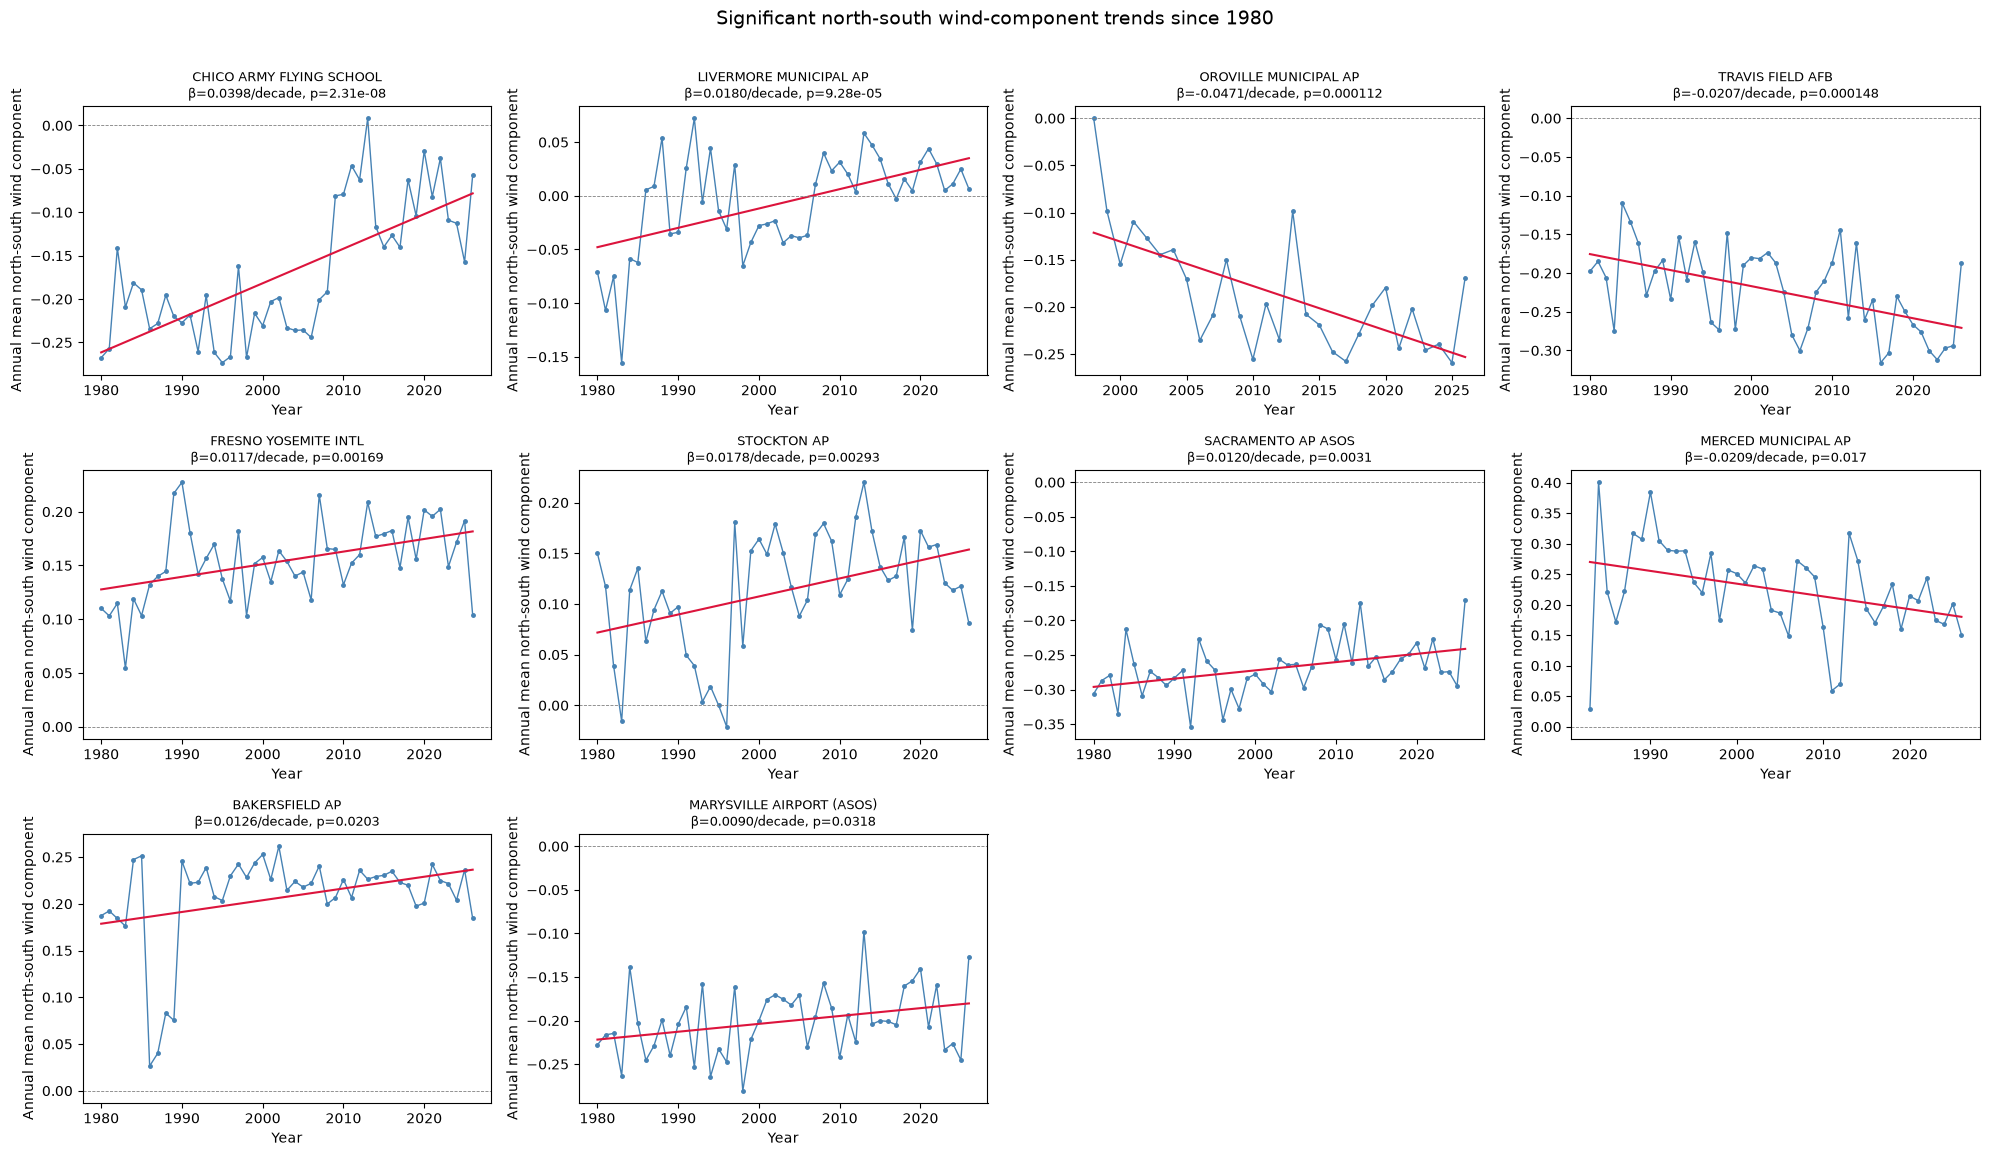

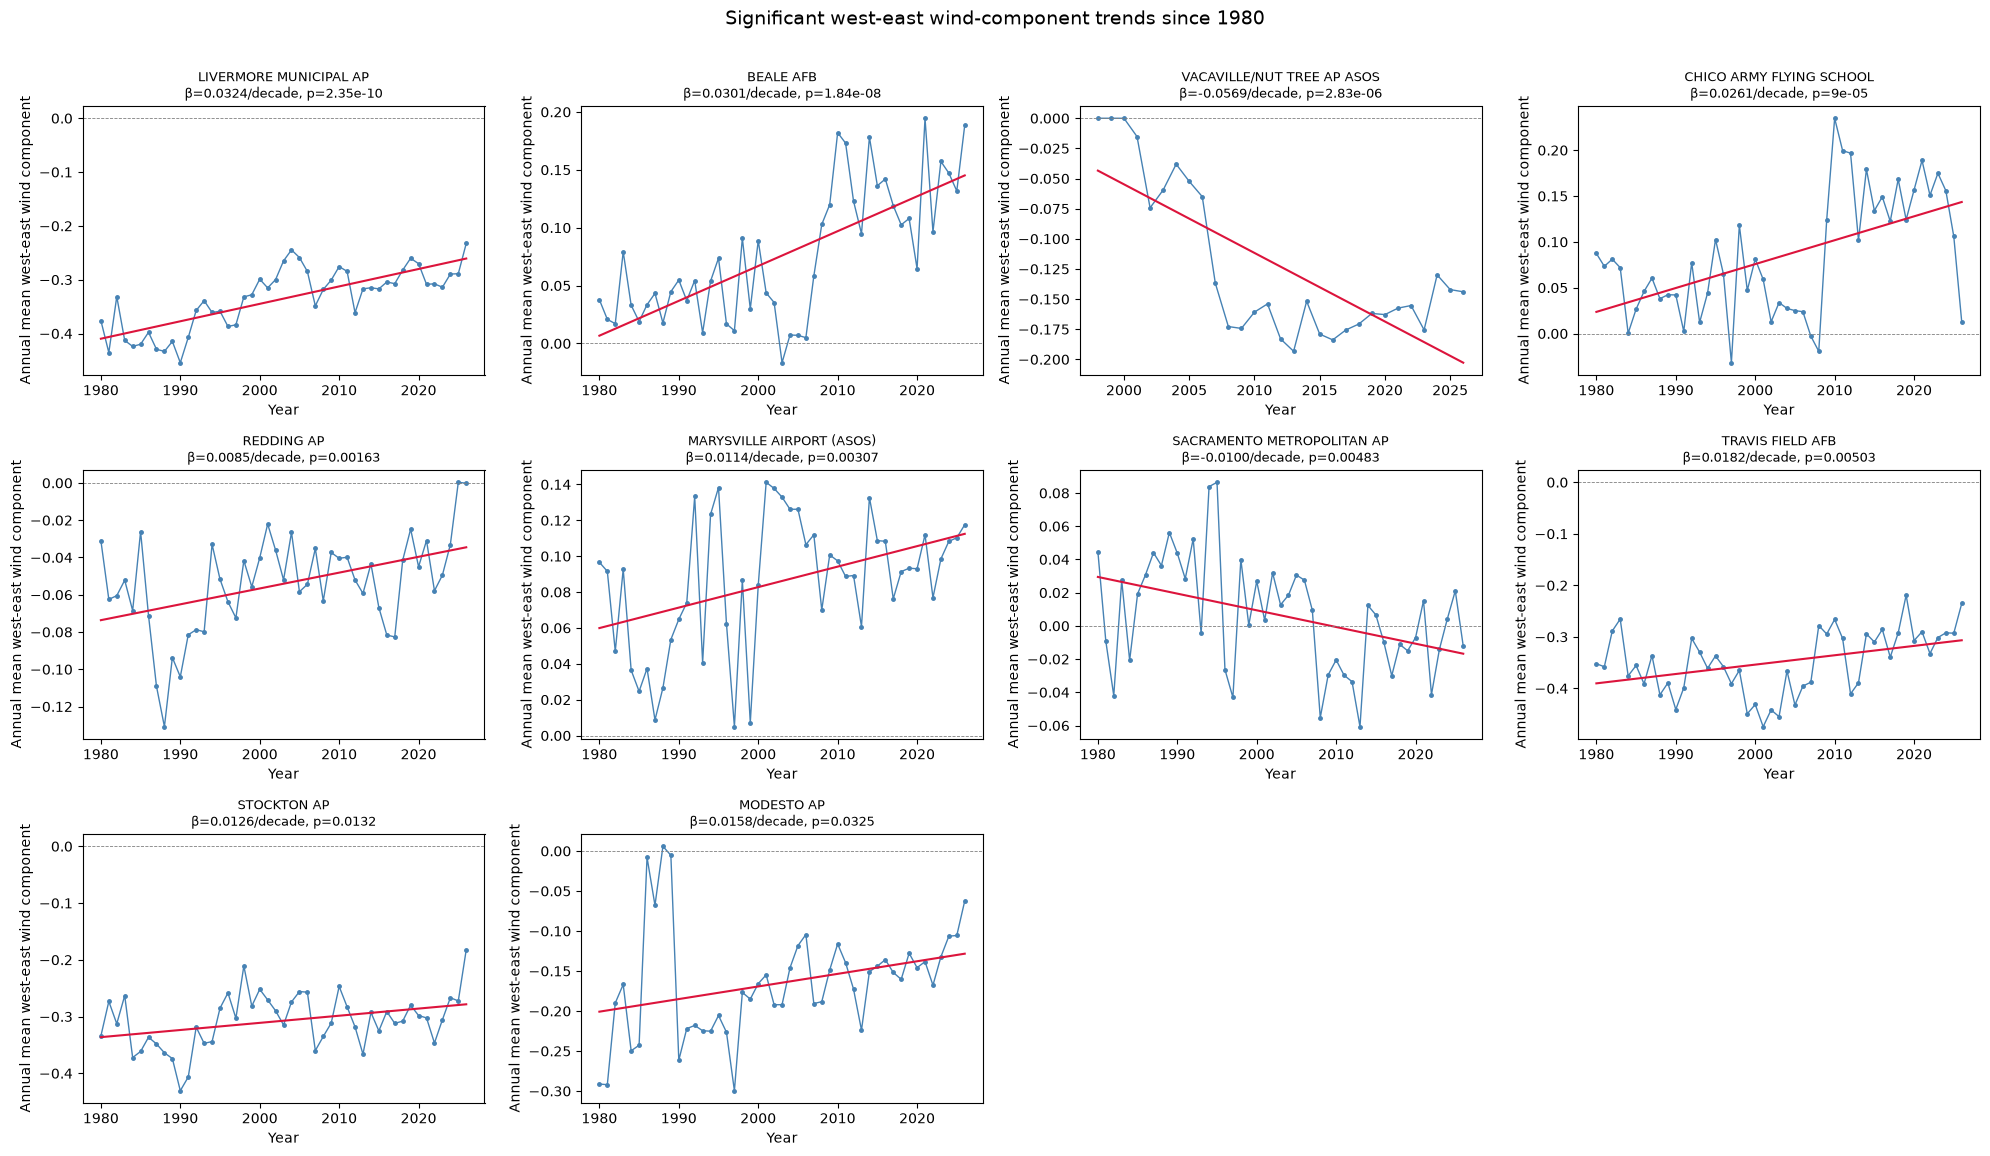

In [31]:
# Trend analysis of annual mean wind components since 1980

# 1) Build annual station means
wind_since_1980 = CV_rows[CV_rows["year"] >= 1980].copy()

# compute annual mean wind components and number of observations per station
annual_wind = (
    wind_since_1980
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        ns_mean=("wind_ns_component", "mean"),
        we_mean=("wind_we_component", "mean"),
        n_obs=("wind_ns_component", "size"),
    )
)

# 2) Fit linear trends by station for each component
min_years = 10
trend_rows = []

# loop through each station and component to fit linear regression and store results
for station, g in annual_wind.groupby("STATION"):
    for col, comp_name in [("ns_mean", "north_south"), ("we_mean", "west_east")]:
        d = g[["year", col]].dropna()
        if d["year"].nunique() < min_years:
            continue

        x = d["year"].to_numpy()
        y = d[col].to_numpy()
        fit = stats.linregress(x, y)

        trend_rows.append({
            "STATION": station,
            "component": comp_name,
            "n_years": int(d["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_value": fit.rvalue,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
trend_df = pd.DataFrame(trend_rows)
sig_trends = trend_df[trend_df["p_value"] < 0.05].copy()

print(f"Total station-component trends tested: {len(trend_df)}")
print(f"Significant trends (p < 0.05): {len(sig_trends)}")
print(sig_trends.sort_values(["component", "p_value"]).head(20))

# 3) Plot significant trends for each component
for comp_name, col, ylab in [
    ("north_south", "ns_mean", "Annual mean north-south wind component"),
    ("west_east", "we_mean", "Annual mean west-east wind component"),
]:
    sig_comp = sig_trends[sig_trends["component"] == comp_name].sort_values("p_value")
    stations = sig_comp["STATION"].tolist()

    if len(stations) == 0:
        print(f"No significant {comp_name} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

# Loop through each station and plot the annual mean wind component and the fitted trend line
    for i, station in enumerate(stations):
        ax = axes[i]
        d = annual_wind[annual_wind["STATION"] == station][["year", col]].dropna().sort_values("year")
        t = sig_comp[sig_comp["STATION"] == station].iloc[0]

        ax.plot(d["year"], d[col], marker="o", linewidth=1, markersize=2.5, color="steelblue")
        ax.plot(
            d["year"],
            t["intercept"] + t["slope_per_year"] * d["year"],
            color="crimson",
            linewidth=1.5
        )
        ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
        ax.set_title(
            f"{station}\nβ={t['slope_per_decade']:.4f}/decade, p={t['p_value']:.3g}",
            fontsize=9
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(ylab)

    for j in range(len(stations), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Significant {comp_name.replace('_', '-') } wind-component trends since 1980", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [32]:
# Redefine valley axes by latitude and classify winds on along-/cross-valley axes
valley_angle = 330.0  # interpreted as the up-valley flow direction (toward 330°)


# Numeric wind fields
wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")  # "from" direction
ws = pd.to_numeric(CV_rows["HourlyWindSpeed"], errors="coerce")

# Convert to "to" direction (direction wind blows toward)
wd_to = (wd + 180.0) % 360.0

# Latitude-dependent up-valley axis:
#   >= 38°N -> 330°
#   <  38°N -> 150°
CV_rows["up_valley_angle_lat"] = np.where(CV_rows["LATITUDE"] >= 38.0, 330.0, 150.0)

# Along-valley alignment (signed, unitless): +up-valley, -down-valley
delta_along = np.deg2rad(wd_to - CV_rows["up_valley_angle_lat"])
CV_rows["valley_along_component_lat"] = np.cos(delta_along)

# Cross-valley axis fixed as perpendicular to 330° (i.e., 60°)
cross_axis_330 = (valley_angle + 90.0) % 360.0
delta_cross = np.deg2rad(wd_to - cross_axis_330)
CV_rows["cross_valley_component_330"] = np.cos(delta_cross)

# Optional speed-weighted components
CV_rows["valley_along_component_lat_ws"] = CV_rows["valley_along_component_lat"] * ws
CV_rows["cross_valley_component_330_ws"] = CV_rows["cross_valley_component_330"] * ws

# Masks
missing_mask = wd.isna() | ws.isna()
calm_mask = wd.eq(0) | ws.eq(0)

# Along-axis classification (latitude-dependent valley axis)
CV_rows["valley_along_type_lat"] = np.select(
    [
        missing_mask,
        calm_mask,
        CV_rows["valley_along_component_lat"] > 0,
        CV_rows["valley_along_component_lat"] < 0,
    ],
    ["missing", "calm", "up_valley", "down_valley"],
    default="neutral"
)

# Cross-axis classification (perpendicular to 330° axis)
CV_rows["cross_valley_type_330"] = np.select(
    [
        missing_mask,
        calm_mask,
        CV_rows["cross_valley_component_330"] > 0,
        CV_rows["cross_valley_component_330"] < 0,
    ],
    ["missing", "calm", "cross_pos", "cross_neg"],
    default="neutral"
)

# Combined category on the two axes
CV_rows["wind_axis_category"] = np.where(
    missing_mask, "missing",
    np.where(
        calm_mask, "calm",
        CV_rows["valley_along_type_lat"] + "__" + CV_rows["cross_valley_type_330"]
    )
)

# Quick check
display(
    CV_rows[
        [
            "STATION", "LATITUDE", "HourlyWindDirection", "HourlyWindSpeed",
            "up_valley_angle_lat", "valley_along_component_lat", "cross_valley_component_330",
            "valley_along_type_lat", "cross_valley_type_330", "wind_axis_category"
        ]
    ].head(12)
)

display(CV_rows["wind_axis_category"].value_counts(dropna=False).head(20))

,STATION,LATITUDE,HourlyWindDirection,HourlyWindSpeed,up_valley_angle_lat,valley_along_component_lat,cross_valley_component_330,valley_along_type_lat,cross_valley_type_330,wind_axis_category
0,GARDNER AAF,35.117,0.0,0.0,150.0,0.866025,-0.500000,calm,calm,calm
1,GARDNER AAF,35.117,158.0,0.5,150.0,-0.990268,0.139173,down_valley,cross_pos,down_valley__cross_pos
2,GARDNER AAF,35.117,0.0,0.0,150.0,0.866025,-0.500000,calm,calm,calm
3,GARDNER AAF,35.117,225.0,0.5,150.0,-0.258819,0.965926,down_valley,cross_pos,down_valley__cross_pos
4,GARDNER AAF,35.117,225.0,0.5,150.0,-0.258819,0.965926,down_valley,cross_pos,down_valley__cross_pos
5,GARDNER AAF,35.117,0.0,0.0,150.0,0.866025,-0.500000,calm,calm,calm
6,GARDNER AAF,35.117,45.0,0.5,150.0,0.258819,-0.965926,up_valley,cross_neg,up_valley__cross_neg
7,GARDNER AAF,35.117,315.0,0.5,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
8,GARDNER AAF,35.117,90.0,0.5,150.0,-0.500000,-0.866025,down_valley,cross_neg,down_valley__cross_neg
9,GARDNER AAF,35.117,0.0,0.0,150.0,0.866025,-0.500000,calm,calm,calm


wind_axis_category
up_valley__cross_pos      4781570
calm                      3445456
up_valley__cross_neg      2448513
down_valley__cross_neg    1961590
down_valley__cross_pos    1858706
Name: count, dtype: int64

                    STATION    component  n_years  slope_pct_per_year  slope_pct_per_decade  r_squared  p_value  significant
             BAKERSFIELD AP cross_valley       47            0.000000              0.000000        NaN      NaN        False
                  BEALE AFB cross_valley       47            0.000000              0.000000        NaN      NaN        False
                 CASTLE AFB cross_valley       39            0.000000              0.000000        NaN      NaN        False
   CHICO ARMY FLYING SCHOOL cross_valley       47            0.000000              0.000000        NaN      NaN        False
FRESNO CHANDLER DOWNTOWN AP cross_valley       14            0.000000              0.000000        NaN      NaN        False
       FRESNO YOSEMITE INTL cross_valley       47            0.000000              0.000000        NaN      NaN        False
       HANFORD MUNICIPAL AP cross_valley       29            0.000000              0.000000        NaN      NaN        False


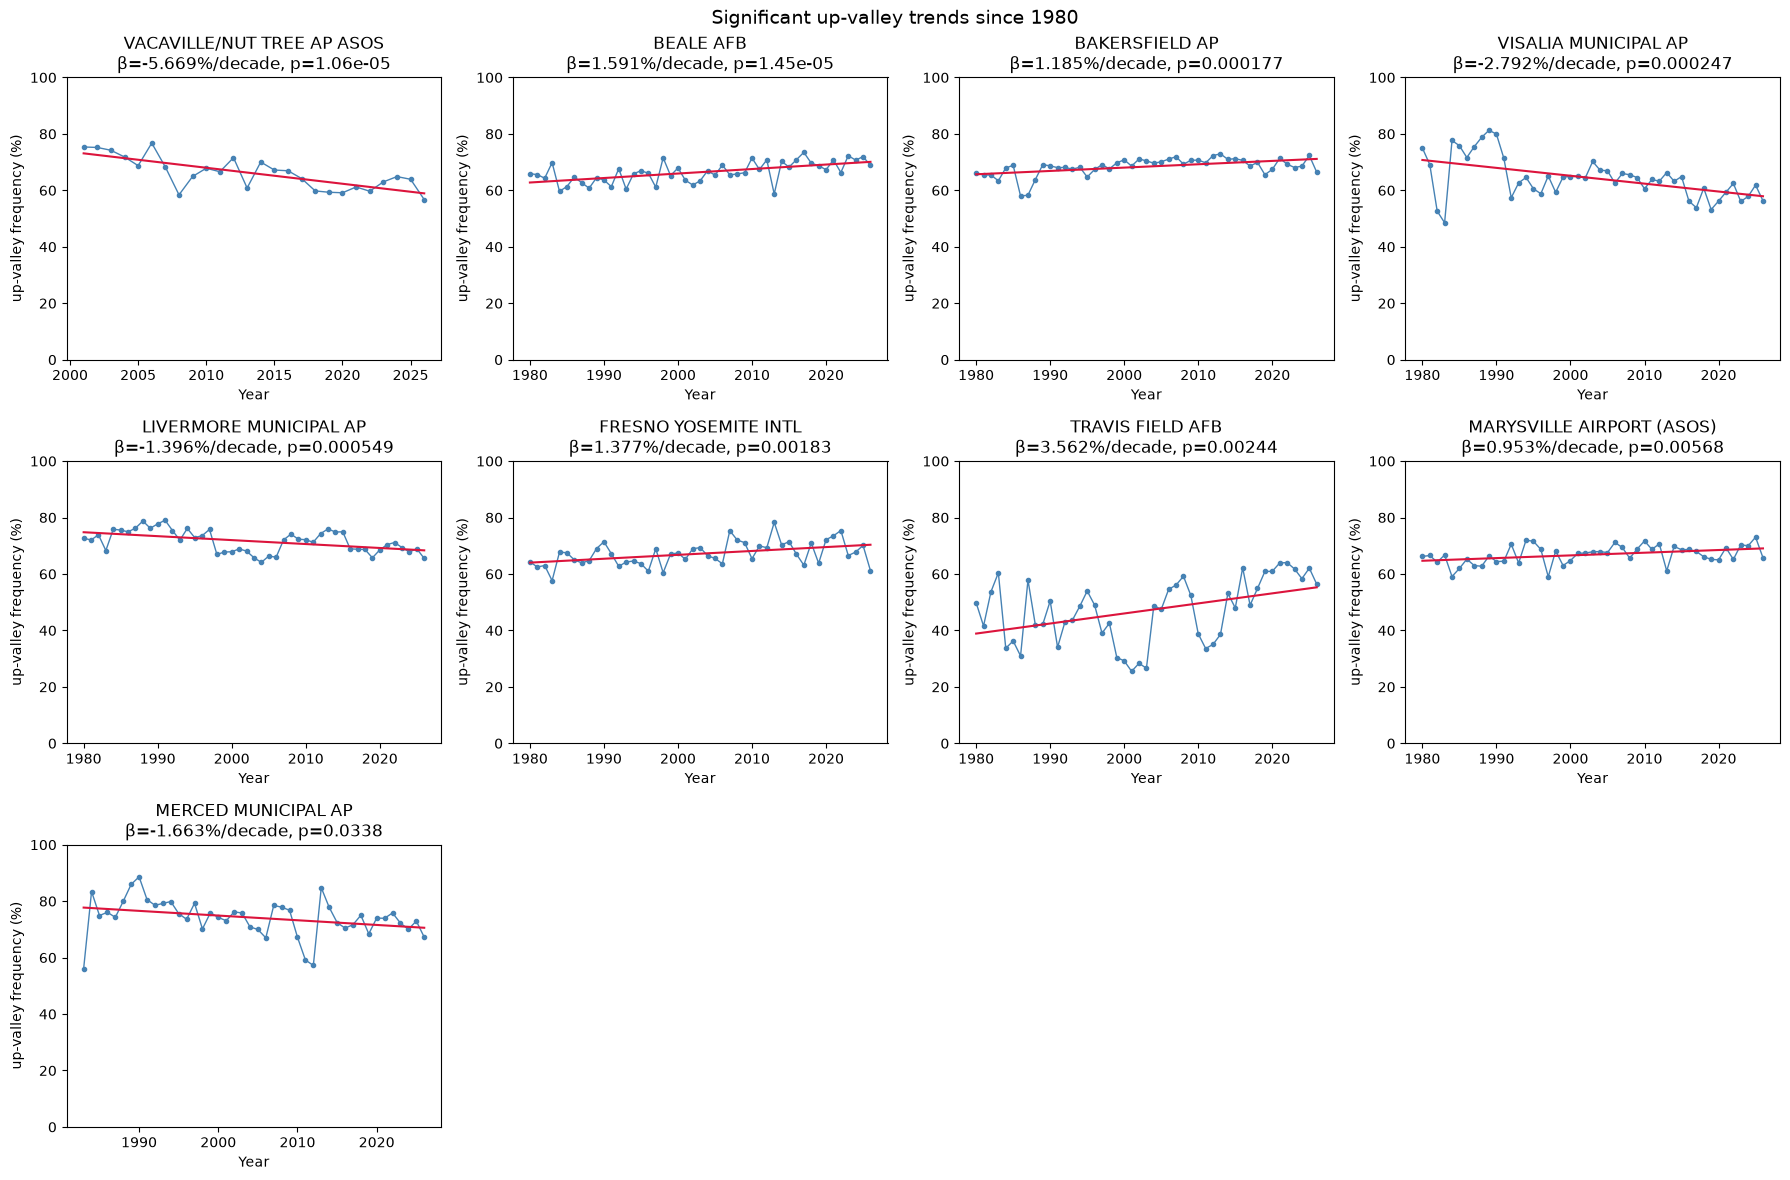

No significant cross-valley trends found.


In [34]:
# Annual up-valley and cross-valley frequency trends since 1980

trend_data = CV_rows.loc[CV_rows["year"] >= 1980].copy()

# Use non-calm, non-missing observations as the denominator
valid_wind = (
    ~trend_data["valley_along_type_lat"].isin(["calm", "missing"])
    & ~trend_data["cross_valley_type_330"].isin(["calm", "missing"])
)
trend_data = trend_data[valid_wind].copy()

# Define mutually independent indicators:
# up-valley = positive along-valley component
# cross-valley = either cross-valley direction
trend_data["up_valley"] = (
    trend_data["valley_along_type_lat"] == "up_valley"
).astype(int)

trend_data["cross_valley"] = (
    trend_data["cross_valley_type_330"].isin(["cross_pos", "cross_neg"])
).astype(int)

# Calculate annual percentages by station
annual_axis_freq = (
    trend_data
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        up_valley_pct=("up_valley", lambda x: 100 * x.mean()),
        cross_valley_pct=("cross_valley", lambda x: 100 * x.mean()),
        n_obs=("up_valley", "size"),
    )
)

# Fit linear trends
axis_trend_rows = []

for station, group in annual_axis_freq.groupby("STATION"):
    for component in ["up_valley_pct", "cross_valley_pct"]:
        d = group[["year", component]].dropna()

        if d["year"].nunique() < 10:
            continue

        fit = stats.linregress(d["year"], d[component])

        axis_trend_rows.append({
            "STATION": station,
            "component": component.replace("_pct", ""),
            "n_years": d["year"].nunique(),
            "slope_pct_per_year": fit.slope,
            "slope_pct_per_decade": fit.slope * 10,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

axis_trends = pd.DataFrame(axis_trend_rows)
axis_trends["significant"] = axis_trends["p_value"] < 0.05

print(axis_trends.sort_values(["component", "p_value"]).to_string(index=False))

# Plot significant trends
for component in ["up_valley", "cross_valley"]:
    sig = axis_trends[
        (axis_trends["component"] == component)
        & axis_trends["significant"]
    ].sort_values("p_value")

    if sig.empty:
        print(f"No significant {component.replace('_', '-')} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(sig) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(18, 4 * nrows), squeeze=False
    )
    axes = axes.ravel()

    value_col = f"{component}_pct"

    for ax, (_, result) in zip(axes, sig.iterrows()):
        station_data = annual_axis_freq[
            annual_axis_freq["STATION"] == result["STATION"]
        ].sort_values("year")

        ax.plot(
            station_data["year"],
            station_data[value_col],
            marker="o",
            markersize=3,
            linewidth=1,
            color="steelblue",
        )

        ax.plot(
            station_data["year"],
            result["slope_pct_per_year"] * station_data["year"]
            + (
                station_data[value_col].mean()
                - result["slope_pct_per_year"] * station_data["year"].mean()
            ),
            color="crimson",
            linewidth=1.5,
        )

        ax.set_title(
            f"{result['STATION']}\n"
            f"β={result['slope_pct_per_decade']:.3f}%/decade, "
            f"p={result['p_value']:.3g}"
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"{component.replace('_', '-')} frequency (%)")
        ax.set_ylim(0, 100)

    for ax in axes[len(sig):]:
        ax.remove()

    fig.suptitle(
        f"Significant {component.replace('_', '-')} trends since 1980",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

In [35]:
# Up-/down-valley trend analysis for fog events only (HourlyVisibility < 1.0) since 1980

# Start from low-visibility event table built earlier
fog_ev = low_vis_events.copy()

# # Ensure datetime
# if not pd.api.types.is_datetime64_any_dtype(fog_ev["DATE"]):
#     fog_ev["DATE"] = pd.to_datetime(fog_ev["DATE"], errors="coerce")

# Recompute valley alignment on fog-event observations
wd_fog = pd.to_numeric(fog_ev["HourlyWindDirection"], errors="coerce")
ws_fog = pd.to_numeric(fog_ev["HourlyWindSpeed"], errors="coerce")
# wd_to_fog is the wind direction plus 180 degrees, representing the direction the wind is blowing toward
# wrapped to 360 degrees meaning that 0° and 360° are equivalent
wd_to_fog = (wd_fog + 180.0) % 360.0
alignment_fog = np.cos(np.deg2rad(wd_to_fog - valley_angle))

# Classify each fog-event observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
fog_ev["obs_valley_type"] = np.select(
    [
        wd_fog.isna() | ws_fog.isna(),
        wd_fog.eq(0) | ws_fog.eq(0),
        alignment_fog > 0,
        alignment_fog < 0,
    ],
    ["missing", "calm", "up_valley", "down_valley"],
    default="cross_valley",
)

# Keep years since 1980
fog_ev = fog_ev[fog_ev["year"] >= 1980].copy()

# Classify each event by dominant valley direction (up vs down)
event_type = (
    fog_ev[fog_ev["obs_valley_type"].isin(["up_valley", "down_valley"])]
    .groupby(["STATION", "event_id", "year", "obs_valley_type"], as_index=False)
    .size()
    .pivot_table(
        index=["STATION", "event_id", "year"],
        columns="obs_valley_type",
        values="size",
        fill_value=0
    )
    .reset_index()
)

# Ensure that both "up_valley" and "down_valley" columns exist in the event_type DataFrame
for c in ["up_valley", "down_valley"]:
    if c not in event_type.columns:
        event_type[c] = 0

# Classify each event as "up_valley", "down_valley", or "tie" based on the counts of up-valley and down-valley observations
event_type["event_wind_type"] = np.select(
    [event_type["up_valley"] > event_type["down_valley"],
     event_type["down_valley"] > event_type["up_valley"]],
    ["up_valley", "down_valley"],
    default="tie"
)

event_type = event_type[event_type["event_wind_type"].isin(["up_valley", "down_valley"])].copy()

# Annual event counts and percentages by station
annual_fog_event_valley = (
    event_type
    .groupby(["STATION", "year", "event_wind_type"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

# compute total events per station-year
annual_fog_event_valley["total"] = annual_fog_event_valley.groupby(["STATION", "year"])["count"].transform("sum")
# computer percentage of each wind type per station-year
annual_fog_event_valley["pct"] = 100 * annual_fog_event_valley["count"] / annual_fog_event_valley["total"]

# Trend fitting
fog_event_trend_rows = []
min_years = 10

# loop through each station and wind type to fit linear regression and store results
for station, g in annual_fog_event_valley.groupby("STATION"):
    for wind_type in ["up_valley", "down_valley"]:
        d = g[g["event_wind_type"] == wind_type][["year", "pct"]].dropna()
        if d["year"].nunique() < min_years:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d["pct"].to_numpy())
        fog_event_trend_rows.append({
            "STATION": station,
            "wind_type": wind_type,
            "n_years": int(d["year"].nunique()),
            "slope_per_year_pct": fit.slope,
            "slope_per_decade_pct": fit.slope * 10,
            "intercept": fit.intercept,
            "r_value": fit.rvalue,
            "r_squared": fit.rvalue**2,
            "p_value": fit.pvalue,
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
fog_event_valley_trend_df = pd.DataFrame(fog_event_trend_rows)
fog_event_valley_sig_trends = fog_event_valley_trend_df[fog_event_valley_trend_df["p_value"] < 0.05].copy()

# print the number of total trends tested and significant trends found
print(f"Total fog-event station-category trends tested: {len(fog_event_valley_trend_df)}")
print(f"Significant fog-event trends (p < 0.05): {len(fog_event_valley_sig_trends)}")
print(fog_event_valley_sig_trends.sort_values(["wind_type", "p_value"]).head(20))

Total fog-event station-category trends tested: 46
Significant fog-event trends (p < 0.05): 4
                       STATION    wind_type  n_years  slope_per_year_pct  \
9         FRESNO YOSEMITE INTL  down_valley       41            0.434969   
37  SACRAMENTO METROPOLITAN AP  down_valley       37            0.502240   
8         FRESNO YOSEMITE INTL    up_valley       41           -0.434969   
36  SACRAMENTO METROPOLITAN AP    up_valley       37           -0.502240   

    slope_per_decade_pct    intercept   r_value  r_squared   p_value   std_err  
9               4.349691  -834.625106  0.492418   0.242475  0.001074  0.123109  
37              5.022396  -948.718675  0.514609   0.264822  0.001119  0.141448  
8              -4.349691   934.625106 -0.492418   0.242475  0.001074  0.123109  
36             -5.022396  1048.718675 -0.514609   0.264822  0.001119  0.141448  


Station-category trends tested: 45
Significant trends (p < 0.05): 12


,STATION,category,n_years,slope_pct_per_year,slope_pct_per_decade,intercept,r_squared,p_value
9,FRESNO YOSEMITE INTL,cross_valley,41,-0.544046,-5.440459,1128.294806,0.319685,0.000117
44,VISALIA MUNICIPAL AP,cross_valley,15,1.072927,10.729272,-2117.814345,0.491766,0.003579
35,SACRAMENTO MCCLELLAN AFB,cross_valley,23,-0.331131,-3.311310,687.999795,0.249523,0.015230
1,BAKERSFIELD AP,cross_valley,40,-0.363436,-3.634363,760.311806,0.121653,0.027401
27,RED BLUFF MUNI AP,cross_valley,35,0.318549,3.185489,-615.514436,0.137505,0.028310
3,BEALE AFB,cross_valley,22,0.374648,3.746475,-716.329339,0.204749,0.034474
8,FRESNO YOSEMITE INTL,up_valley,41,0.468990,4.689897,-915.463655,0.316558,0.000129
36,SACRAMENTO METROPOLITAN AP,up_valley,37,-0.480615,-4.806150,989.535973,0.273499,0.000897
38,STOCKTON AP,up_valley,41,0.287052,2.870522,-558.373405,0.214621,0.002286
2,BEALE AFB,up_valley,22,-0.356704,-3.567038,739.841559,0.250426,0.017694


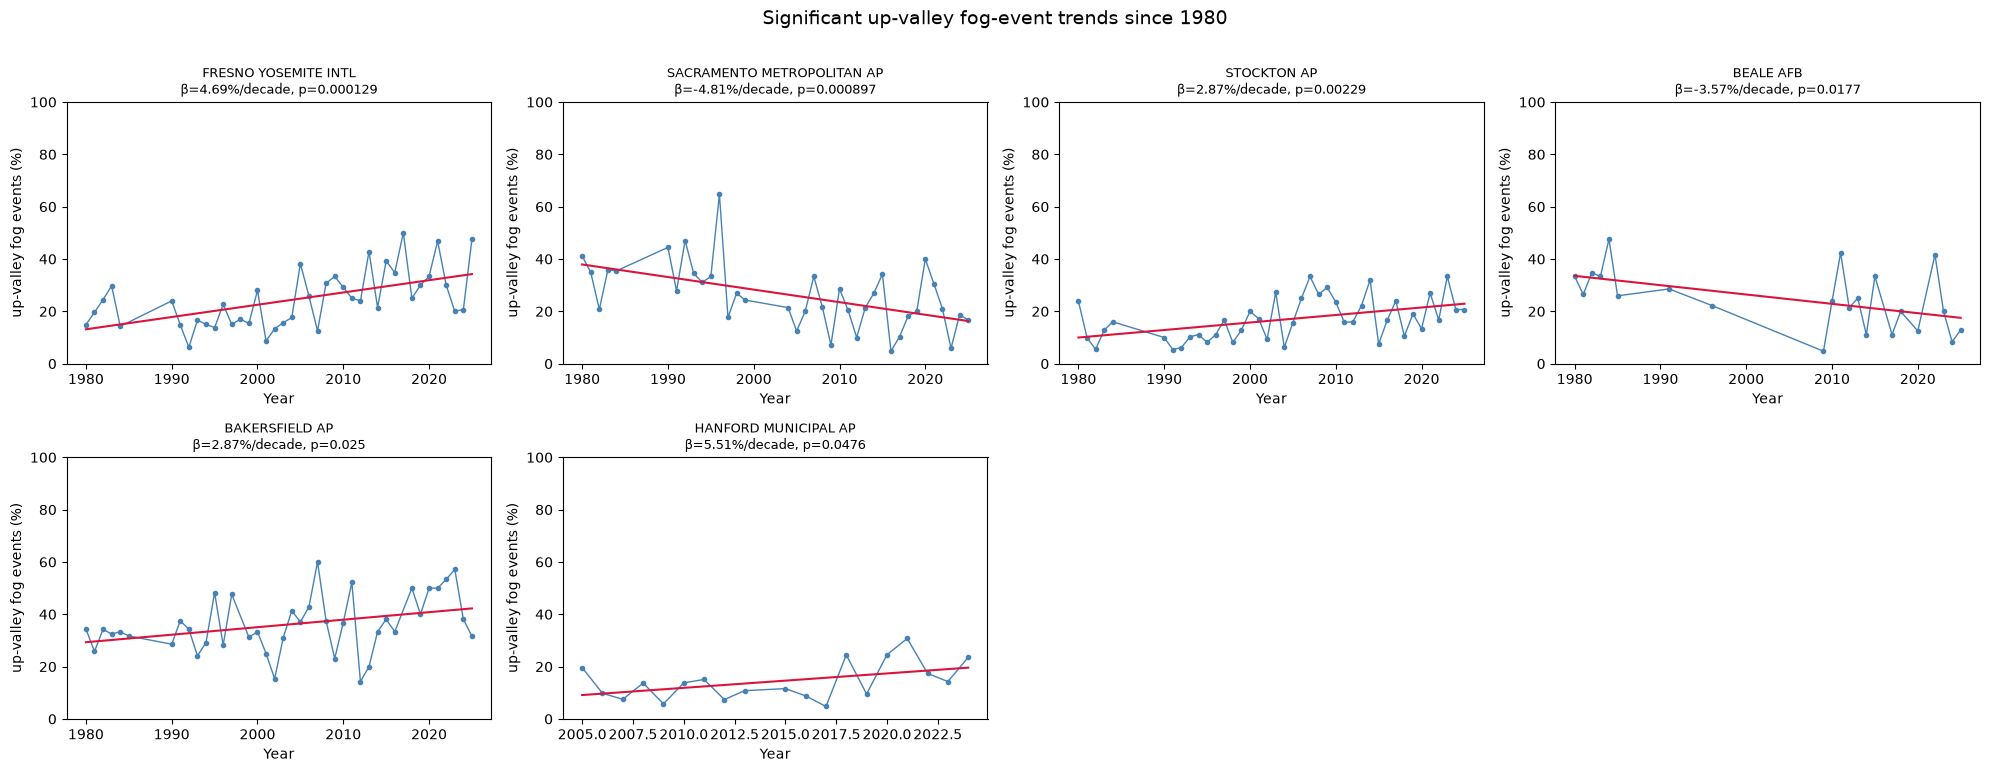

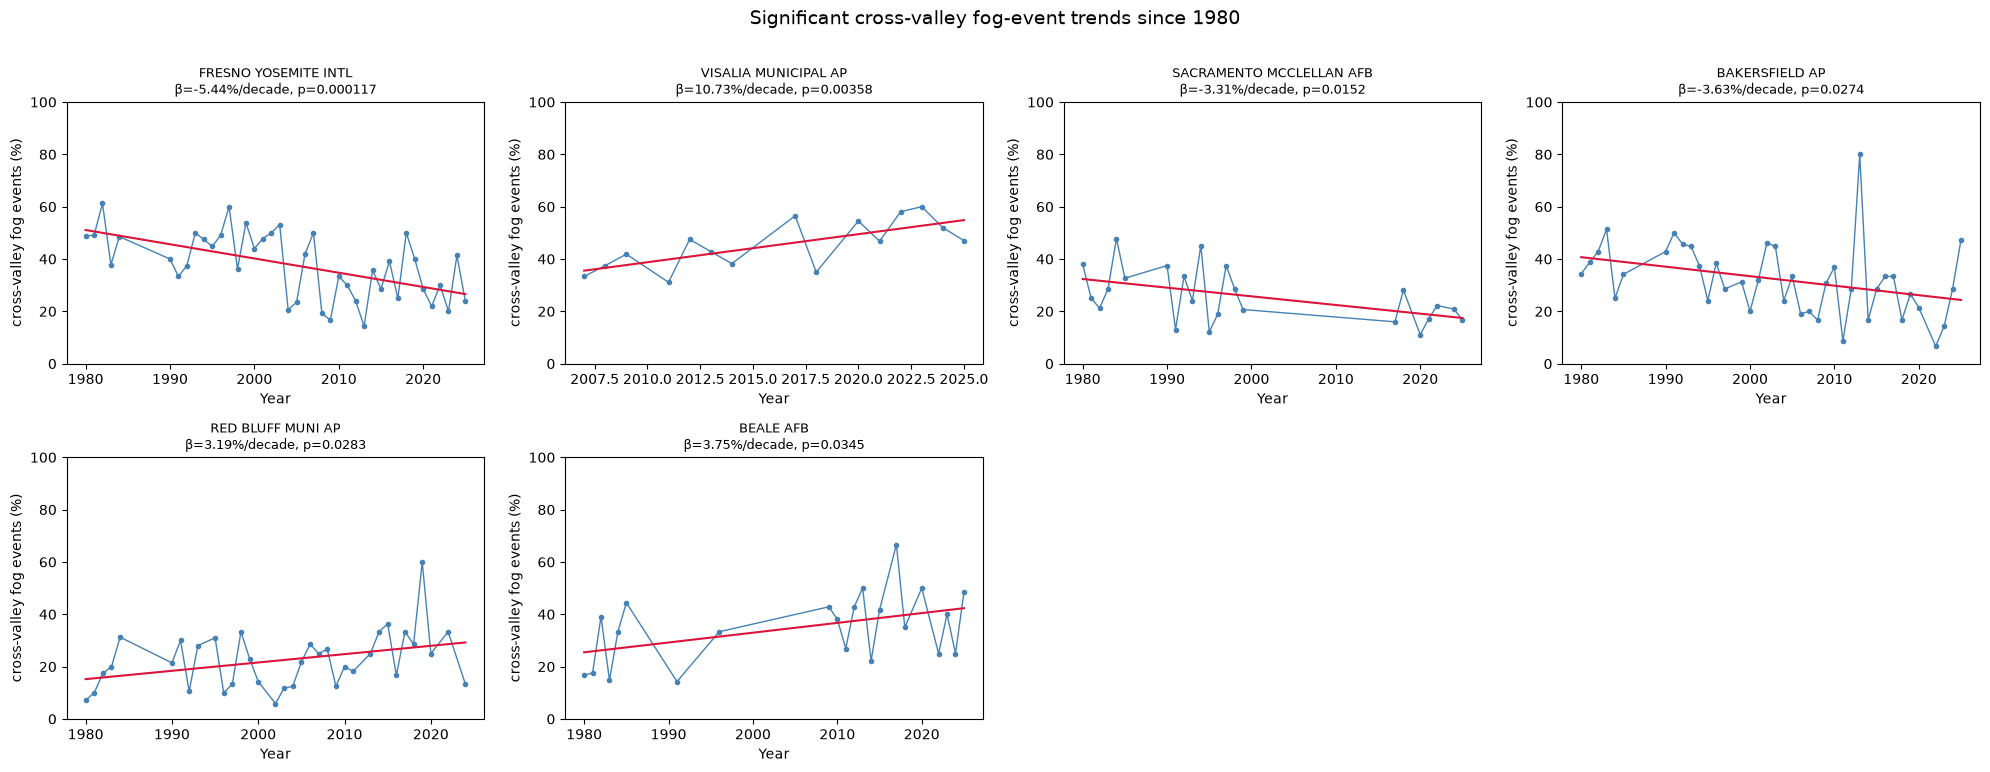

In [36]:
# Analyze significant up-valley and cross-valley trends for low-visibility fog events since 1980

fog_axis = low_vis_events[low_vis_events["year"] >= 1980].copy()

wd_fog = pd.to_numeric(fog_axis["HourlyWindDirection"], errors="coerce")
ws_fog = pd.to_numeric(fog_axis["HourlyWindSpeed"], errors="coerce")
wd_to_fog = (wd_fog + 180.0) % 360.0

# Use the latitude-dependent up-valley axis defined for the full station dataset
fog_axis["up_valley_angle"] = np.where(fog_axis["LATITUDE"] >= 38.0, 330.0, 150.0)
fog_axis["along_component"] = np.cos(
    np.deg2rad(wd_to_fog - fog_axis["up_valley_angle"])
)

# Cross-valley axis is perpendicular to the local along-valley axis
fog_axis["cross_component"] = np.sin(
    np.deg2rad(wd_to_fog - fog_axis["up_valley_angle"])
)

valid_fog_wind = wd_fog.notna() & ws_fog.notna() & wd_fog.ne(0) & ws_fog.ne(0)
along_dominant = fog_axis["along_component"].abs() >= fog_axis["cross_component"].abs()

# Assign each fog observation to one mutually exclusive dominant wind category
fog_axis["fog_wind_category"] = np.select(
    [
        valid_fog_wind & along_dominant & (fog_axis["along_component"] > 0),
        valid_fog_wind & along_dominant & (fog_axis["along_component"] < 0),
        valid_fog_wind & ~along_dominant,
    ],
    ["up_valley", "down_valley", "cross_valley"],
    default="unclassified",
)

# Classify each event by its most frequent observation-level category
event_axis_counts = (
    fog_axis[fog_axis["fog_wind_category"] != "unclassified"]
    .groupby(["STATION", "event_id", "year", "fog_wind_category"], as_index=False)
    .size()
    .rename(columns={"size": "n_observations"})
)

event_axis_type = (
    event_axis_counts
    .sort_values(
        ["STATION", "event_id", "year", "n_observations", "fog_wind_category"],
        ascending=[True, True, True, False, True],
    )
    .drop_duplicates(["STATION", "event_id", "year"])
    .rename(columns={"fog_wind_category": "event_wind_category"})
)

# Annual percentages of events in each category
annual_fog_axis = (
    event_axis_type
    .groupby(["STATION", "year", "event_wind_category"], as_index=False)
    .size()
    .rename(columns={"size": "event_count"})
)

annual_fog_axis["total_events"] = annual_fog_axis.groupby(
    ["STATION", "year"]
)["event_count"].transform("sum")

annual_fog_axis["pct"] = (
    100 * annual_fog_axis["event_count"] / annual_fog_axis["total_events"]
)

# Fit station-level trends for up-valley and cross-valley event percentages
fog_axis_trend_rows = []

for station, group in annual_fog_axis.groupby("STATION"):
    for category in ["up_valley", "cross_valley"]:
        d = group.loc[
            group["event_wind_category"] == category, ["year", "pct"]
        ].dropna()

        if d["year"].nunique() < 10:
            continue

        fit = stats.linregress(d["year"], d["pct"])

        fog_axis_trend_rows.append(
            {
                "STATION": station,
                "category": category,
                "n_years": d["year"].nunique(),
                "slope_pct_per_year": fit.slope,
                "slope_pct_per_decade": fit.slope * 10,
                "intercept": fit.intercept,
                "r_squared": fit.rvalue**2,
                "p_value": fit.pvalue,
            }
        )

fog_axis_trends = pd.DataFrame(fog_axis_trend_rows)
fog_axis_sig_trends = fog_axis_trends[
    fog_axis_trends["p_value"] < 0.05
].copy()

print(f"Station-category trends tested: {len(fog_axis_trends)}")
print(f"Significant trends (p < 0.05): {len(fog_axis_sig_trends)}")
display(fog_axis_sig_trends.sort_values(["category", "p_value"]))

# Plot significant station trends
for category in ["up_valley", "cross_valley"]:
    sig = fog_axis_sig_trends[
        fog_axis_sig_trends["category"] == category
    ].sort_values("p_value")

    if sig.empty:
        print(f"No significant {category.replace('_', '-')} fog-event trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(sig) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows))
    axes = np.asarray(axes).ravel()

    for ax, (_, result) in zip(axes, sig.iterrows()):
        d = annual_fog_axis[
            (annual_fog_axis["STATION"] == result["STATION"])
            & (annual_fog_axis["event_wind_category"] == category)
        ].sort_values("year")

        ax.plot(d["year"], d["pct"], marker="o", markersize=3, linewidth=1,
                color="steelblue")
        ax.plot(
            d["year"],
            result["intercept"] + result["slope_pct_per_year"] * d["year"],
            color="crimson",
            linewidth=1.5,
        )
        ax.set_title(
            f"{result['STATION']}\n"
            f"β={result['slope_pct_per_decade']:.2f}%/decade, "
            f"p={result['p_value']:.3g}",
            fontsize=9,
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"{category.replace('_', '-')} fog events (%)")
        ax.set_ylim(0, 100)

    for ax in axes[len(sig):]:
        fig.delaxes(ax)

    fig.suptitle(
        f"Significant {category.replace('_', '-')} fog-event trends since 1980",
        fontsize=14,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()